In [49]:
# Import required packages for this assignment.

from pathlib import Path

import math
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pylab as plt 

from dmba import regressionSummary, classificationSummary
from dmba import liftChart, gainsChart

from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn import preprocessing

import matplotlib.pylab as plt
import seaborn as sns

%matplotlib inline

In [50]:
# Problem 5.1 (pg. 155)

# A data mining routine has been applied to a transaction dataset and has classified 88 records as fraudulent (30 correctly so) and 952 as non-fraudulent (920 correctly so). Construct the confusion matrix and calculate the overall error rate.

In [51]:
# Answer:

# Theoretical Classification Confusion Matrix
#|----------------------------------------------------------------------------|
#|             |                     Predicted Class                          |
#|----------------------------------------------------------------------------|
#| Actual Class|             C0               |             C1                |
#|----------------------------------------------------------------------------|
#|      C0     | n0,0 = number of correctly   | n0,1 = number of C0 cases     | 
#|             | classified C0 cases          | incorrectly classified as C1  | 
#|----------------------------------------------------------------------------|
#|      C1     | n1,0 = number of C1 cases    | n1,1 = number of correctly    |
#|             | incoreectly classified as C0 | classified C1 cases           |
#|----------------------------------------------------------------------------|

# Applied Classification Confusion Matrix
#|--------------------------------------------------------------|
#|                    |          Predicted Class                |
#|--------------------------------------------------------------|
#| Actual Class       |  Fraudulent (1)  |  Non-fraudulent (0)  |
#|--------------------------------------------------------------|
#| Fraudulent (1)     |        30        |         32           | 
#|--------------------------------------------------------------|
#| Non-fraudulent (0) |        58        |        920           |
#|--------------------------------------------------------------|


# Formula For Overall Error Rate: 

# Overall Error Rate = (n0,1 + n1,0)/ n, where n is the total number of records.

In [52]:
# Overall Error Rate Code For Problem 5.1:

overall_error_rate = (32 + 58) / 1040
overall_error_rate

0.08653846153846154

In [53]:
# Code Output Interpretation For Problem 5.1:

# The overall error rate was 8.65%.

In [54]:
# Problem 5.2 (pg. 155)

# Suppose that this routine has an adjustable cutoff (threshold) mechanism by which you can alter the proportion of records classified as fraudulent. 

# 5.2.a. Describe how moving the cutoff up or down would affect the classification error rate for records that are truly fraudulent.
# 5.2.b. Describe how moving the cutoff up or down would affect the classification error rate for records that are truly non-fraudulent.

In [55]:
# Answer:

# Classification Confusion Matrix
#|--------------------------------------------------------|
#|                   |          Predicted Class           |
#|--------------------------------------------------------|
#| Actual Class      | Fraudulent (1) | Non-fraudulent (0)|
#|--------------------------------------------------------|
#| Fraudulent (1)    |       a        |         b         |
#|--------------------------------------------------------|
#| Non-fraudulent (0)|       c        |         d         |
#|--------------------------------------------------------|

# The classification error rate for truly fraudulent records (with this 0.5 cutoff) is b/(a+b).

# The classification error rate for truly non-fraudulent records (with this 0.5 cutoff) is c/(c+d).

In [56]:
# Increasing the cutoff above 0.5 leads to classifying more records, both fraudulent and non-fraudulent, as non-fraudulent:  b and d both increase, a and c decline.

# a. With respect to the classification error rate for truly fraudulent records, the error rate, b/(a+b), increases as b goes up. As you raise the standard for calling a record fraudulent, you miss more and more of the real frauds.

# b. With respect to the classification error rate for truly non-fraudulent records, the error rate, c/(c+d), decreases as d goes up. As you raise the standard for calling a record fraudulent, fewer non-frauds get mislabeled as frauds.

In [57]:
# Problem 5.5 (pg. 156)

# A large number of insurance records are to be examined to develop a model for predicting fraudulent claims. Of the claims in the historical database, 1% were judged to be fraudulent. A sample is taken 
# to develop a model, and oversampling is used to provide a balanced sample in light of the very low response rate. When applied to this sample (n = 800), the model ends up correctly classifying 310 frauds, 
# and 270 nonfrauds. It missed 90 frauds, and classified 130 records incorrectly as frauds when they were not.

# 5.5.a. Produce the confusion matrix for the sample as it stands.

In [58]:
# Answer:

#Classification Confusion Matrix
#|--------------------------------------------------------|
#|                   |          Predicted Class           |
#|--------------------------------------------------------|
#|    Actual Class   |       1        |        0          |
#|--------------------------------------------------------|
#|          1        |      310       |        90         |
#|--------------------------------------------------------|
#|          0        |      130       |       270         |
#|--------------------------------------------------------|

In [59]:
# Misclassification Rate Code For Problem 5.5.a

misclassification_rate = (90 + 130) / 800
misclassification_rate

0.275

In [60]:
# Code Output Interpretation For Problem 5.5.a:

# The overall misclassification rate was 27.5%.

In [61]:
# The model ends up classifying (310 + 130) / 800 = 0.55 = 55% of the records as fraudulent.

# 5.5.b. Find the adjusted misclassification rate (adjusting for the oversampling).

In [62]:
# Answer:

# Now we need to add enough zeros, so that the 1's only constitute 1% of the total and the 0's constitute 99% of the total (where x is the total).
                                                                                                           
# 400 + 0.99 * x = x
# Therefore x = 40,000
# Number of zeros = 0.99 * 40,000 = 39,600

# Classification Confusion Matrix
#|-------------------------------------------------------------|
#|                   |          Predicted Class       |        |
#|-------------------------------------------------------------|
#|    Actual Class   |       1       |        0       |  Total |
#|-------------------------------------------------------------|
#|         1         |      310      |        90      |   400  |
#|----------------------------------------------------|--------|
#|         0         |    12,870     |     26,730     | 39,600 |
#|----------------------------------------------------|--------|
#|       Total       |    13,180     |     26,820     | 40,000 |
#|-------------------------------------------------------------|

In [63]:
# Adjusted Misclassification Rate Code For Problem 5.5.b:

adj_misclassification_rates = (90 + 12870) / 40000
adj_misclassification_rates

0.324

In [64]:
# Code Output Interpretation For Problem 5.5.b:

# The overall adjusted misclassification rate was 32.4%.

In [65]:
# 5.5.c. What percentage of new records would you expect to be classified as fraudulent?

# The model ends up classifying (310 + 12,870) / 40,000 = 0.3295 = 32.95% of the records as fraudulent.

In [66]:
# Problem 5.7 (pg. 157)

# Table 5.7 shows a small set of predictive model validation results for a classification model, with both actual values and propensities.

# 5.7.a.  Calculate error rates, sensitivity, and specificity using cutoffs of 0.25, 0.5, and 0.75.

In [67]:
# Create a data frame from Table 5.7 data.

data = {'Propensity': [0.03, 0.52, 0.38, 0.82, 0.33, 0.42, 0.55, 0.59, 0.09, 0.21, 0.43, 0.04, 0.08, 0.13, 0.01, 0.79, 0.42, 
                       0.29, 0.08, 0.02],
        'Actual': [0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]}

# Convert to data frame.
df = pd.DataFrame(data)

In [68]:
# Cutoff = 0.25

Predicted = [1 if p > 0.25 else 0 for p in df.Propensity]
classificationSummary(df.Actual, Predicted, class_names=['0', '1'])

Confusion Matrix (Accuracy 0.6000)

       Prediction
Actual 0 1
     0 9 8
     1 0 3


In [69]:
# Overall Error Rate (with 0.25 cutoff)
error_rate = (8) / 20
print('\nError Rate = ', error_rate)
# Sensitivity (with 0.25 cutoff)
sensitivity = (3) / (3+0)
print('\nSensitivity=',sensitivity)
# Specificity (with 0.25 cutoff)
specificity = (9) / (8+9)
print('\nSpecificity = ', specificity)


Error Rate =  0.4

Sensitivity= 1.0

Specificity =  0.5294117647058824


In [70]:
# Cutoff = 0.5

Predicted = [1 if p > 0.5 else 0 for p in df.Propensity]
classificationSummary(df.Actual, Predicted, class_names=['0', '1'])

Confusion Matrix (Accuracy 0.9000)

       Prediction
Actual  0  1
     0 15  2
     1  0  3


In [71]:
# Overall Error Rate (with 0.5 cutoff)
error_rate = (2) / 20
print('\nError Rate = ', error_rate)
# Sensitivity (with 0.5 cutoff)
sensitivity = (3) / (3+0)
print('\nSensitivity=',sensitivity)
# Specificity (with 0.5 cutoff)
specificity = (15) / (2+15)
print('\nSpecificity = ', specificity)


Error Rate =  0.1

Sensitivity= 1.0

Specificity =  0.8823529411764706


In [72]:
# Cutoff = 0.75

Predicted = [1 if p > 0.75 else 0 for p in df.Propensity]
classificationSummary(df.Actual, Predicted, class_names=['0', '1'])

Confusion Matrix (Accuracy 0.9500)

       Prediction
Actual  0  1
     0 17  0
     1  1  2


In [73]:
# Overall Error Rate (with 0.75 cutoff)
error_rate = (1) / 20
print('\nError Rate = ', error_rate)
# Sensitivity (with 0.75 cutoff)
sensitivity = (2) / (2+1)
print('\nSensitivity=',sensitivity)
# Specificity (with 0.75 cutoff)
specificity = (17) / (0+17)
print('\nSpecificity = ', specificity)


Error Rate =  0.05

Sensitivity= 0.6666666666666666

Specificity =  1.0


In [74]:
# 5.7.b.  Create a decile lift chart.

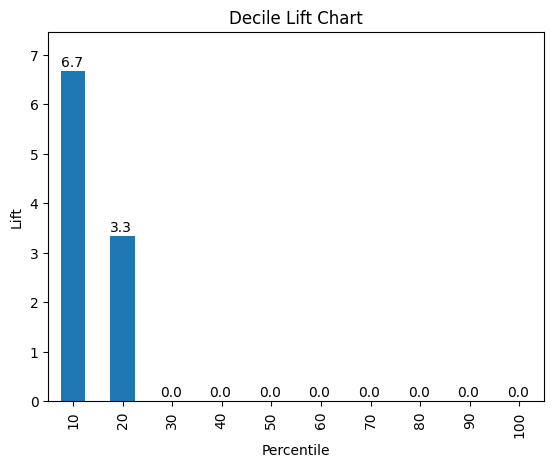

In [75]:
# Sort data by propensities.
df = df.sort_values(by=['Propensity'], ascending=False)

# Generate decile lift chart.
liftChart(df.Actual)
plt.show()

In [76]:
# 4.8 Principal Components Analysis - Example 2: Breakfast Cereals

In [77]:
# Load required data.
cereals_df = pd.read_csv('Course Data/dmba/Cereals.csv')

# Show the data frame.
cereals_df

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100%_Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.0,25,3,1.0,0.33,68.402973
1,100%_Natural_Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.0,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.0,25,3,1.0,0.33,59.425505
3,All-Bran_with_Extra_Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.0,25,3,1.0,0.50,93.704912
4,Almond_Delight,R,C,110,2,2,200,1.0,14.0,8.0,NaN,25,3,1.0,0.75,34.384843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,Triples,G,C,110,2,1,250,0.0,21.0,3.0,60.0,25,3,1.0,0.75,39.106174
73,Trix,G,C,110,1,1,140,0.0,13.0,12.0,25.0,25,2,1.0,1.00,27.753301
74,Wheat_Chex,R,C,100,3,1,230,3.0,17.0,3.0,115.0,25,1,1.0,0.67,49.787445
75,Wheaties,G,C,100,3,1,200,3.0,17.0,3.0,110.0,25,1,1.0,1.00,51.592193


In [78]:
# PCA On The Two Variables Calories And Rating - TABLE 4.11

# Code For Running PCA
pcs = PCA(n_components=2)
pcs.fit(cereals_df[['calories', 'rating']])

PCA(n_components=2)

In [79]:
# The importance of components can be assessed using the explained variance.

# pcsSummary
pcsSummary = pd.DataFrame({'Standard deviation': np.sqrt(pcs.explained_variance_),
                           'Proportion of variance': pcs.explained_variance_ratio_,
                           'Cumulative proportion': np.cumsum(pcs.explained_variance_ratio_)})
pcsSummary = pcsSummary.transpose()
pcsSummary.columns = ['PC1', 'PC2']
pcsSummary.round(4)

,PC1,PC2
Standard deviation,22.3165,8.8844
Proportion of variance,0.8632,0.1368
Cumulative proportion,0.8632,1.0000


In [80]:
# The `components_` field of `pcs` gives the individual components. The columns in this matrix are the principal components `PC1`, `PC2`. The rows are variables in the order they are found in the input matrix, `calories` and `rating`.

# Components
pcsComponents_df = pd.DataFrame(pcs.components_.transpose(), columns=['PC1', 'PC2'], 
                                index=['calories', 'rating'])
pcsComponents_df

,PC1,PC2
calories,0.847053,0.531508
rating,-0.531508,0.847053


In [81]:
# Use the `transform` method to get the scores.

# Scores
scores = pd.DataFrame(pcs.transform(cereals_df[['calories', 'rating']]), 
                      columns=['PC1', 'PC2'])
scores.head()

,PC1,PC2
0,-44.921528,2.197183
1,15.725265,-0.382416
2,-40.149935,-5.407212
3,-75.310772,12.999126
4,7.041508,-5.357686


In [82]:
#PCA Output Using All 13 Numerical Variables In The Breakfast Cereal Dataset - TABLE 4.12

In [83]:
# pcsSummary
pcs = PCA()
pcs.fit(cereals_df.iloc[:, 3:].dropna(axis=0))
pcsSummary_df = pd.DataFrame({'Standard deviation': np.sqrt(pcs.explained_variance_),
                           'Proportion of variance': pcs.explained_variance_ratio_,
                           'Cumulative proportion': np.cumsum(pcs.explained_variance_ratio_)})
pcsSummary_df = pcsSummary_df.transpose()
pcsSummary_df.columns = ['PC{}'.format(i) for i in range(1, len(pcsSummary_df.columns) + 1)]
pcsSummary_df.round(4)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
Standard deviation,83.7641,70.9143,22.6437,19.1815,8.4232,2.0917,1.6994,0.7796,0.6578,0.3704,0.1864,0.063,0.0
Proportion of variance,0.5395,0.3867,0.0394,0.0283,0.0055,0.0003,0.0002,0.0000,0.0000,0.0000,0.0000,0.000,0.0
Cumulative proportion,0.5395,0.9262,0.9656,0.9939,0.9993,0.9997,0.9999,1.0000,1.0000,1.0000,1.0000,1.000,1.0


In [84]:
# Generate table that shows results for the first five principal components.
pcsComponents_df = pd.DataFrame(pcs.components_.transpose(), columns=pcsSummary_df.columns, 
                                index=cereals_df.iloc[:, 3:].columns)
pcsComponents_df.iloc[:,:5]

,PC1,PC2,PC3,PC4,PC5
calories,0.077984,-0.009312,0.629206,-0.601021,0.454959
protein,-0.000757,0.008801,0.001026,0.003200,0.056176
fat,-0.000102,0.002699,0.016196,-0.025262,-0.016098
sodium,0.980215,0.140896,-0.135902,-0.000968,0.013948
fiber,-0.005413,0.030681,-0.018191,0.020472,0.013605
carbo,0.017246,-0.016783,0.017370,0.025948,0.349267
sugars,0.002989,-0.000253,0.097705,-0.115481,-0.299066
potass,-0.134900,0.986562,0.036782,-0.042176,-0.047151
vitamins,0.094293,0.016729,0.691978,0.714118,-0.037009
shelf,-0.001541,0.004360,0.012489,0.005647,-0.007876


In [85]:
#PCA Output Using All Normalized 13 Variables In The Breakfast Cereal Dataset - TABLE 4.13

In [86]:
# Normalized pcsSummary
pcs = PCA()
pcs.fit(preprocessing.scale(cereals_df.iloc[:, 3:].dropna(axis=0)))
pcsSummary_df = pd.DataFrame({'Standard deviation': np.sqrt(pcs.explained_variance_),
                           'Proportion of variance': pcs.explained_variance_ratio_,
                           'Cumulative proportion': np.cumsum(pcs.explained_variance_ratio_)})
pcsSummary_df = pcsSummary_df.transpose()
pcsSummary_df.columns = ['PC{}'.format(i) for i in range(1, len(pcsSummary_df.columns) + 1)]
pcsSummary_df.round(4)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
Standard deviation,1.9192,1.7864,1.3912,1.0166,1.0015,0.8555,0.8251,0.6496,0.5658,0.3051,0.2537,0.1399,0.0
Proportion of variance,0.2795,0.2422,0.1469,0.0784,0.0761,0.0555,0.0517,0.0320,0.0243,0.0071,0.0049,0.0015,0.0
Cumulative proportion,0.2795,0.5217,0.6685,0.7470,0.8231,0.8786,0.9303,0.9623,0.9866,0.9936,0.9985,1.0000,1.0


In [87]:
# Generate table that shows results for the first five principal components.
pcsComponents_df = pd.DataFrame(pcs.components_.transpose(), columns=pcsSummary_df.columns, 
                                index=cereals_df.iloc[:, 3:].columns)
pcsComponents_df.iloc[:,:5]

,PC1,PC2,PC3,PC4,PC5
calories,-0.299542,0.393148,0.114857,-0.204359,0.203899
protein,0.307356,0.165323,0.277282,-0.300743,0.319749
fat,-0.039915,0.345724,-0.204890,-0.186833,0.586893
sodium,-0.183397,0.137221,0.389431,-0.120337,-0.338364
fiber,0.453490,0.179812,0.069766,-0.039174,-0.255119
carbo,-0.192449,-0.149448,0.562452,-0.087835,0.182743
sugars,-0.228068,0.351434,-0.355405,0.022707,-0.314872
potass,0.401964,0.300544,0.067620,-0.090878,-0.148360
vitamins,-0.115980,0.172909,0.387859,0.604111,-0.049287
shelf,0.171263,0.265050,-0.001531,0.638879,0.329101


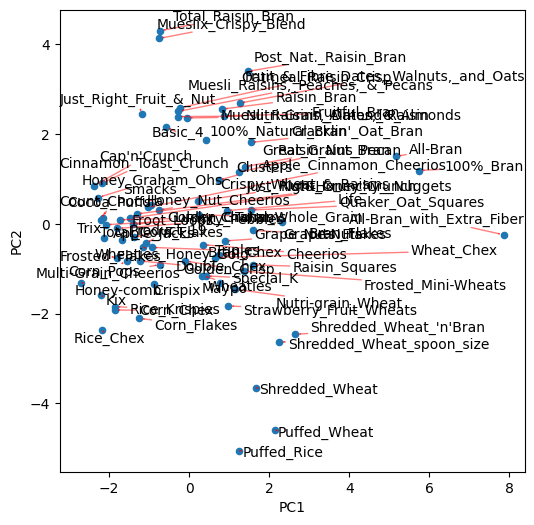

In [88]:
# Using Principal Components For Classification And Prediction

# Generate scatterplot of the second vs. first principal component scores for the normalized breakfast cereal output.
from adjustText import adjust_text
cereals_red_df = cereals_df.dropna(axis=0)
cereals_red_df = cereals_red_df.reset_index(drop=True)

scores = pd.DataFrame(pcs.fit_transform(preprocessing.scale(cereals_red_df.iloc[:, 3:].dropna(axis=0))), 
                      columns=[f'PC{i}' for i in range(1, 14)])
cereals_pca_df = pd.concat([cereals_red_df['name'].dropna(axis=0), scores[['PC1', 'PC2']]], axis=1)
ax = cereals_pca_df.plot.scatter(x='PC1', y='PC2', figsize=(6, 6))
points = cereals_pca_df[['PC1','PC2','name']]

texts = []
for _, (x, y, s) in points.iterrows():
        texts.append(ax.text(x, y, s))
adjust_text(texts, force_text=0.05, arrowprops=dict(arrowstyle="-|>", color='r', alpha=0.5))

plt.show()

c:\Users\rcc_0\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\rcc_0\AppData\Local\Temp\ipykernel_18308\3956427377.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  points.groupby(['cluster']).apply(lambda g: extractPoint(g, texts))


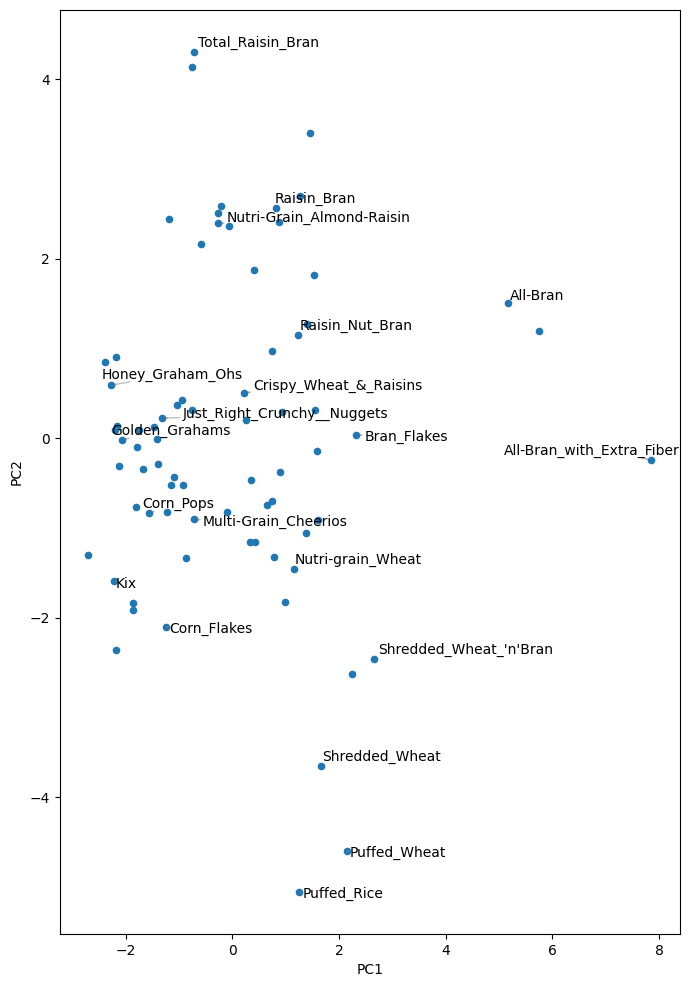

In [89]:
# Using Principal Components For Classification And Prediction With kmeans Cluster Reduction

# Generate scatterplot of the second vs. first principal component scores for the normalized breakfast cereal output.
from sklearn.cluster import KMeans

cereals_pca_df = pd.concat([cereals_df['name'], scores], axis=1) #ignore_index=True)
ax = cereals_pca_df.plot.scatter(x='PC1', y='PC2', figsize=(8, 12))
points = pd.DataFrame(points)

def extractPoint(df, texts):
    for _, (x, y, s) in df.sample(1)[['PC1','PC2','name']].iterrows():
        texts.append(ax.text(x, y, s))

kmeans = KMeans(n_clusters=20, random_state=0).fit(points[['PC1', 'PC2']])
points['cluster'] = kmeans.labels_
texts = []
points.groupby(['cluster']).apply(lambda g: extractPoint(g, texts))

adjust_text(texts, force_text=0.05, arrowprops=dict(arrowstyle="-|>", color='grey', alpha=0.5))

plt.show()

In [90]:
# Problem 4.3 (pg. 120) - Sales Of Toyota Corolla Cars

# The file _ToyotaCorolla.csv_ contains data on used cars (Toyota Corollas) on sale during late summer of 2004 in the Netherlands. It has 1436 records containing details on 38 attributes, 
# including Price, Age, Kilometers, HP, and other specifications. The goal will be to predict the price of a used Toyota Corolla based on its specifications.

# 4.3.a Identify the categorical variables.

In [91]:
# Load the required data.
toyota_df = pd.read_csv('Course Data/dmba/ToyotaCorolla.csv')

# Find the dimensions of the data frame.
toyota_df.shape

(1436, 39)

In [92]:
# List variable types.
toyota_df.dtypes

Id                    int64
Model                object
Price                 int64
Age_08_04             int64
Mfg_Month             int64
Mfg_Year              int64
KM                    int64
Fuel_Type            object
HP                    int64
Met_Color             int64
Color                object
Automatic             int64
CC                    int64
Doors                 int64
Cylinders             int64
Gears                 int64
Quarterly_Tax         int64
Weight                int64
Mfr_Guarantee         int64
BOVAG_Guarantee       int64
Guarantee_Period      int64
ABS                   int64
Airbag_1              int64
Airbag_2              int64
Airco                 int64
Automatic_airco       int64
Boardcomputer         int64
CD_Player             int64
Central_Lock          int64
Powered_Windows       int64
Power_Steering        int64
Radio                 int64
Mistlamps             int64
Sport_Model           int64
Backseat_Divider      int64
Metallic_Rim        

In [93]:
# Categorical Variables
# Fuel_Type                Fuel Type (Petrol, Diesel, CNG)
# Color                    Color (Blue, Red, Grey, Silver, Black, etc.)
# Met_Color                Metallic Color? (Yes=1, No=0)
# Automatic                Automatic ( (Yes=1, No=0)
# Mfr_Guarantee            Within Manufacturer's Guarantee period (Yes=1, No=0)
# BOVAG_Guarantee          BOVAG (Dutch dealer network) Guarantee (Yes=1, No=0)
# ABS                      Anti-Lock Brake System (Yes=1, No=0)
# Airbag_1                 Driver_Airbag (Yes=1, No=0)
# Airbag_2                 Passenger Airbag (Yes=1, No=0)
# Airco                    Airconditioning (Yes=1, No=0)
# Automatic_airco          Automatic Airconditioning (Yes=1, No=0)
# Boardcomputer            Boardcomputer (Yes=1, No=0)
# CD_Player                CD Player (Yes=1, No=0)
# Central_Lock             Central Lock (Yes=1, No=0)
# Powered_Windows          Powered Windows (Yes=1, No=0)
# Power_Steering           Power Steering (Yes=1, No=0)
# Radio                    Radio (Yes=1, No=0)
# Mistlamps                Mistlamps (Yes=1, No=0)
# Sport_Model              Sport Model (Yes=1, No=0)
# Backseat_Divider         Backseat Divider (Yes=1, No=0)
# Metallic_Rim             Metallic Rim (Yes=1, No=0)
# Radio_cassette           Radio Cassette (Yes=1, No=0)
# Parking_Assistant        Parking assistance system (Yes=1, No=0)
# Tow_Bar                  Tow Bar (Yes=1, No=0)

In [94]:
# 4.3.b. Explain the relationship between a categorical variable and the series of binary dummy variables derived from it.

# A variable with N categories will be transformed into N dummy variables, with each dummy indicating whether a certain category is present or not. For example, 
# Fuel type has 3 categories: Petrol, Diesel, and CNG. If we convert it to dummy variables, we get 3 dummy variables: Fuel_Type_Petrol (if the fuel type is Petrol 
# then Fuel_Type_Petrol=1, otherwise Fuel_Type_Petrol=0),  Fuel_Type_Diesel (if the fuel type is Diesel then Fuel_Type_Diesel=1, otherwise Fuel_Type_Diesel=0) and 
# Fuel_Type_CNG (if the fuel type is CNG then Fuel_Type_CNG=1, otherwise Fuel_Type_CNG=0). Note that when the first two dummies both have values of 0, it indicates 
# that the fuel type is CNG.

In [95]:
# 4.3.c. How many dummy binary variables are required to capture the information in a categorical variable with N categories?

# N-1 binary variables are required to capture the information in a categorical variable with N categories. Note that in some routines, e.g. linear regression and 
# logistic regression, use of all N dummies will cause the routine to fail because the nth variable contains redundant information and can be expressed as a linear 
# combination of the others. Only N-1 variables should be used (they contain all the available information about the variable from which they were derived).

In [96]:
# 4.3.d. Use Python to convert the categorical variables in this dataset into dummy variables, and explain in words, for one record, the values in the derived binary dummies.

# When we convert Fuel type into dummy variables, we get Fuel_Type_Diesel, Fuel_Type_Petrol and Fuel_Type_CNG. For the 1st record Fuel type is Diesel. Values in dummy 
# variables are as follows: Fuel_Type_Diesel = 1, Fuel_Type_Petrol = 0, Fuel_Type_CNG = 0.

# Note: That not all 42 variables are shown in the output showing some initial observations below. 

In [97]:
# Create dummy variables for Fuel_Type.
df_fuel_type = pd.get_dummies(toyota_df['Fuel_Type'])

# Append new dummy variables to the original data set.
new_df = pd.concat([toyota_df, df_fuel_type], axis=1)

# Show first five records in new data set.
new_df.head()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar,CNG,Diesel,Petrol
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,0,0,1,0,0,0,0,False,True,False
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,0,1,0,0,0,0,False,True,False
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,0,1,0,0,0,0,False,True,False
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,0,1,0,0,0,0,False,True,False
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,0,1,0,0,0,0,False,True,False


In [98]:
# 4.3.e. Use Python to produce a correlation matrix and matrix plot. Comment on the relationships among variables.

In [99]:
# Generate correlation matrix.
corr_df = new_df[['Price', 'Age_08_04', 'KM', 'HP', 'CC', 'Quarterly_Tax', 'Weight']]
corr = corr_df.corr()
corr

,Price,Age_08_04,KM,HP,CC,Quarterly_Tax,Weight
Price,1.000000,-0.876590,-0.569960,0.314990,0.126389,0.219197,0.581198
Age_08_04,-0.876590,1.000000,0.505672,-0.156622,-0.098084,-0.198431,-0.470253
KM,-0.569960,0.505672,1.000000,-0.333538,0.102683,0.278165,-0.028598
HP,0.314990,-0.156622,-0.333538,1.000000,0.035856,-0.298432,0.089614
CC,0.126389,-0.098084,0.102683,0.035856,1.000000,0.306996,0.335637
Quarterly_Tax,0.219197,-0.198431,0.278165,-0.298432,0.306996,1.000000,0.626134
Weight,0.581198,-0.470253,-0.028598,0.089614,0.335637,0.626134,1.000000


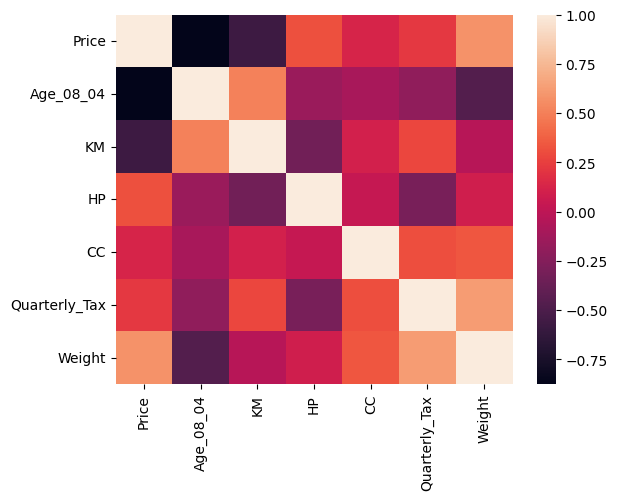

In [100]:
# Generate correlation heatmap.
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns)

plt.show()

In [101]:
# Commentary #4.3.e

# Price has a strong negative correlation with Age_08_04. This makes sense, because the older the car is, the less it will cost.
# Price has a notable negative correlation with KM.  This makes sense, because the more accumulated kilometers on the odometer, 
# the less it will cost. Age_08_04 has a notable positive correlation with KM.  This makes sense, because the older the car is, 
# the more accumulated kilometers on the odometer. Weight has a notable positive correlation with Price and Quarterly_Tax.  This 
# makes sense, because the heavier the car is, the more it will cost and the more tax that could be assessed.